In [ ]:
### Compute Constraint ###

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Function to process the file and extract columns
def read_and_process_file(file_path):
    with open(file_path, 'r') as f:
        # Read the entire file and split into lines
        lines = f.readlines()
    
    # Convert each line to a list of floats (each line is a row)
    data = [list(map(float, line.split())) for line in lines]
    
    # Transpose to columns
    return list(zip(*data))  # Each column is now a list

# Function to read blocks from the data file
def read_blocks(file_path):
    with open(file_path, 'r') as f:
        blocks = f.read().strip().split("\n\n")
    return [block.strip() for block in blocks]

# Function to read the times from the time file
def read_times(time_file_path):
    with open(time_file_path, 'r') as f:
        times = [float(line.strip()) for line in f.readlines()]
    return times

# Function to process a block into columns (x, y1, y2, y3)
def process_block(block):
    data = [list(map(float, line.split())) for line in block.split("\n")]
    return list(zip(*data))  # Transpose to columns

# Values calculated in Mathematica notebook
path = '../ModifiedCL/lphi4Inflation/'
analytic = '../Analytics/lphi4InflationCL/'
f_star = 5.198666686881212e+19
M_p = 2.435e18
omega_star =  1643962752658602.2


# Read and process the data
avg_scalar = read_and_process_file(path + 'average_scalar_0.txt')
avg_sf = read_and_process_file(path + 'average_scale_factor.txt')
avg_energies = read_and_process_file(path + 'average_energies.txt')
avg_energies_conservation = read_and_process_file(path + 'average_energy_conservation.txt')
spectra_blocks = read_blocks(path + 'spectra_scalar_0.txt')
spectra_times = read_times(path + 'average_spectra_times.txt')

# Read scale factors and times then create interpolation
t = np.array(avg_sf[0])
a = np.array(avg_sf[1])
a_t = UnivariateSpline(t, a, s=0) # I use _t to denote, 'as a function of t'

# Read the Hubble then create interpolation
Hubble = np.array(avg_sf[3]) * omega_star/M_p
Hubble_t = UnivariateSpline(t,Hubble,s=0)

# Define horizon wavevector then create interpolation
kh = Hubble * a
kh_t = UnivariateSpline(t, kh, s=0)

# Read field velocity and times then create interpolation
phi = np.array(avg_scalar[1]) * f_star/M_p
phi_t = UnivariateSpline(t,phi,s=0)
dphi = np.array(avg_scalar[2]) * f_star * omega_star / M_p**2 # Time derivative is w.r.t. cosmic time
dphi_t = UnivariateSpline(t,dphi,s=0)
V = np.array(avg_energies[3]) * (f_star * omega_star)**2 / M_p**4
V_t = UnivariateSpline(t,V,s=0)
dV_t = UnivariateSpline(t,V,s=0).derivative

# Define epsilon
def epsilon_t(t):
    return 0.5 * dphi_t(t)**2 / (Hubble_t(t)**2)

ddphi_t_calc = dphi_t.derivative()

def ddphi_t(t):
    return ddphi_t_calc(t)  * omega_star / M_p

def eta_t(t):
    return -ddphi_t(t) / (Hubble_t(t) * dphi_t(t))

# Indices of the spectra blocks to plot
indices_to_plot = [i for i in range(0, int(len(spectra_blocks)/10), 1)] # Divide by 10 to only print first 20% of evolution

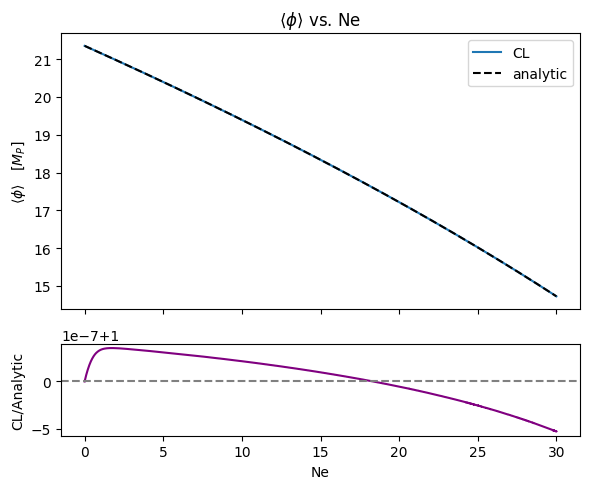

In [15]:
# Interpolate chi onto log(a) = Ne to match phi's domain
data = np.loadtxt(analytic+"phi_vs_Ne.txt")
Ne = data[:, 0] 
chi = data[:, 1]
chi_interp = UnivariateSpline(Ne, chi,s=0)
chi_on_phi_domain = chi_interp(np.log(a))


# Compute the ratio
ratio = phi / chi_on_phi_domain
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 5), gridspec_kw={'height_ratios': [3, 1]})
mask = (a >= np.exp(0)) & (a <= np.exp(30))

# use the mask on y arrays
phi2 = phi[mask]
chi_on_phi_domain2 = chi_on_phi_domain[mask]
a2 = a[mask]
ratio2 = ratio[mask]

# Top plot: main comparison
ax1.plot(np.log(a2), phi2, label='CL')
ax1.plot(np.log(a2), chi_on_phi_domain2, label='analytic', color='black', linestyle='--')
ax1.set_ylabel(r'$\langle\phi\rangle\quad [M_P]$')
ax1.set_title(r'$\langle\phi\rangle$ vs. Ne')
ax1.legend()
# Bottom plot: ratio
ax2.plot(np.log(a2), ratio2, label='CL / analytic', color='purple')
ax2.axhline(1.0, color='gray', linestyle='--')
ax2.set_xlabel(r'Ne')
ax2.set_ylabel('CL/Analytic')
plt.tight_layout()
plt.show()


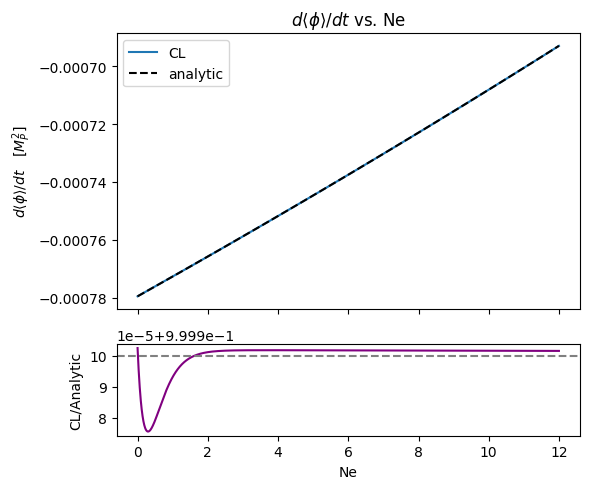

In [16]:
# Interpolate chi onto log(a) = Ne to match phi's domain
data = np.loadtxt(analytic + "dphidt_vs_Ne.txt")
Ne = data[:, 0] 
dchi = data[:, 1]
dchi_interp = UnivariateSpline(Ne, dchi,s=0)
dchi_on_phi_domain = dchi_interp(np.log(a))

# Compute the ratio
ratio = (dphi) / dchi_on_phi_domain

mask = (a >= 0) & (a <= np.exp(12))

# use the mask on y arrays
dphi2 = dphi[mask]
dchi_on_phi_domain2 = dchi_on_phi_domain[mask]
a2 = a[mask]
ratio2 = ratio[mask]

# Create the figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 5), gridspec_kw={'height_ratios': [3, 1]})

# Top plot: main comparison
ax1.plot(np.log(a2), dphi2, label='CL')
ax1.plot(np.log(a2), dchi_on_phi_domain2, label='analytic', color='black', linestyle='--')
ax1.set_ylabel(r'$d\langle\phi\rangle/dt\quad [M_P^2]$')
ax1.set_title(r'$d\langle\phi\rangle/dt $ vs. Ne')
ax1.legend()
# Bottom plot: ratio
ax2.plot(np.log(a2), ratio2, label='CL / analytic', color='purple')
ax2.axhline(1.0, color='gray', linestyle='--')
ax2.set_xlabel(r'Ne')
ax2.set_ylabel('CL/Analytic')

plt.tight_layout()

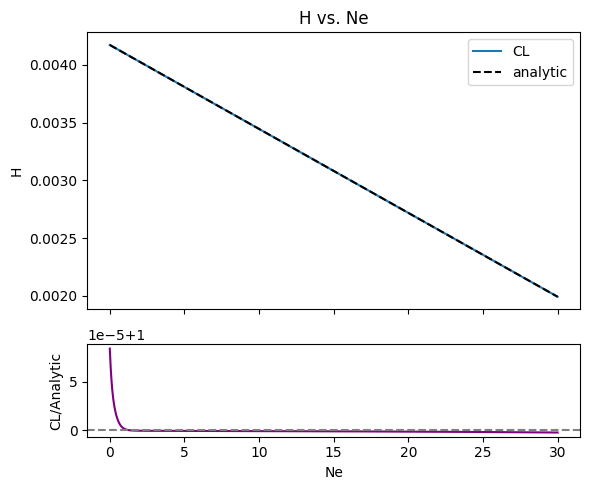

In [17]:
# Interpolate chi onto log(a) = Ne to match phi's domain
data = np.loadtxt(analytic+"H_vs_Ne.txt")
Ne = data[:, 0] 
H = data[:, 1]
H_interp = UnivariateSpline(Ne, H,s=0)
H_on_H_domain = H_interp(np.log(a))

# Compute the ratio
ratio = (Hubble) / H_on_H_domain

# use the mask on y arrays
mask = (a >= 0) & (a <= np.exp(30))
Hubble2 = Hubble[mask]
H_on_H_domain2 = H_on_H_domain[mask]
a2 = a[mask]
ratio2 = ratio[mask]

# Create the figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 5), gridspec_kw={'height_ratios': [3, 1]})

# Top plot: main comparison
ax1.plot(np.log(a2), Hubble2, label='CL')
ax1.plot(np.log(a2), H_on_H_domain2, label='analytic', color='black', linestyle='--')
ax1.set_ylabel(r'H')
ax1.set_title(r'H vs. Ne')
ax1.legend()

# Bottom plot: ratio
ax2.plot(np.log(a2), ratio2, label='CL / analytic', color='purple')
ax2.axhline(1.0, color='gray', linestyle='--')
ax2.set_xlabel(r'Ne')
ax2.set_ylabel('CL/Analytic')

plt.tight_layout()
plt.show()

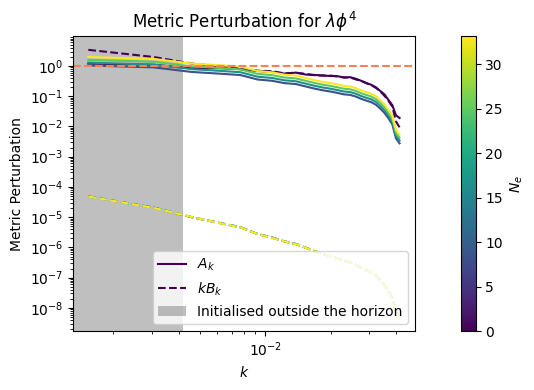

In [ ]:
indices_to_plot = [i for i in range(0, int(len(spectra_blocks)/2), 2000)] # Divide by 10 to only print first 20% of evolution
cmap = cm.viridis
norm = mcolors.Normalize(vmin=min(indices_to_plot), vmax=max(indices_to_plot))


# Plot the power spectrum of phi over time
plt.figure(figsize=[5.5,4])
for idx in indices_to_plot:
    block = spectra_blocks[idx]
    x, y1, y2, y3 = process_block(block)  # Extract data from the block
    k = np.array(x) * omega_star / M_p
    Deltaphi = (np.array(y1)) * f_star**2 / M_p**2
    Pphi = Deltaphi * 2 * np.pi**2 / k**3
    Deltadphi = (np.array(y2)) * f_star**2 * omega_star**2 / M_p**4
    time = spectra_times[idx]
    
    a = a_t(time)
    H = Hubble_t(time)
    phidot = dphi_t(time)
    eps = epsilon_t(time)
    delta_sr = eta_t(time)   # whatever your code calls the second slow-roll parameter

    delta_phi_k = np.sqrt(2 * np.pi**2 / k**3 * Deltaphi)
    delta_dphi_k = np.sqrt(2 * np.pi**2 / k**3 * Deltadphi)

    A_k = eps * H / phidot * delta_phi_k

    B_k = (
        eps * H / phidot
        * (delta_dphi_k + (delta_sr - eps) * H * delta_phi_k)
        / k**2
    )

    shift_metric_k = np.abs(k * B_k)
    plt.plot(k, np.abs(A_k), color=cmap(norm(idx)), linestyle='-', label = "$A_k$" if idx == 0 else None)
    plt.plot(k, shift_metric_k, color=cmap(norm(idx)), linestyle='--', label = "$k B_k$"if idx == 0 else None)

cmap = cm.viridis
norm = mcolors.Normalize(vmin=np.log(a_t(spectra_times[min(indices_to_plot)])), vmax=np.log(a_t(spectra_times[max(indices_to_plot)])))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.1)
cbar.set_label(r'$N_e$')
plt.title("Metric Perturbation for $\lambda \phi^4$")
plt.axvspan(kh_t(0)-1, kh_t(0), facecolor='grey', alpha=.5, label="Initialised outside the horizon")
plt.axhline(1, linestyle="--", color = "coral")
plt.xlabel(r'$k$')
plt.legend(loc='lower right')
plt.ylabel(r'Metric Perturbation')
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig('lphi4_AB.pdf')
plt.show()

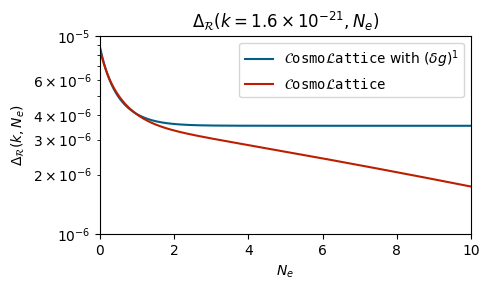

In [ ]:
path2 = '../CL/lphi4Inflation/'
k_extract = 4e-3

def compute_DeltaR(path):
    avg_scalar = read_and_process_file(path + 'average_scalar_0.txt')
    avg_sf = read_and_process_file(path + 'average_scale_factor.txt')
    avg_energies = read_and_process_file(path + 'average_energies.txt')
    spectra_blocks = read_blocks(path + 'spectra_scalar_0.txt')
    spectra_times = read_times(path + 'average_spectra_times.txt')

    t = np.array(avg_sf[0])
    a = np.array(avg_sf[1])
    a_t = UnivariateSpline(t, a, s=0)

    Hubble = np.array(avg_sf[3]) * omega_star / M_p
    Hubble_t = UnivariateSpline(t, Hubble, s=0)

    phi = np.array(avg_scalar[1]) * f_star / M_p
    dphi = np.array(avg_scalar[2]) * f_star * omega_star / M_p**2
    dphi_t = UnivariateSpline(t, dphi, s=0)

    def epsilon_t_local(t):
        return 0.5 * dphi_t(t)**2 / (M_p**2 * Hubble_t(t)**2)

    DeltaR_at_k = []
    a_vals = []

    for idx in range(len(spectra_blocks)):
        x, y1, y2, y3 = process_block(spectra_blocks[idx])
        k = np.array(x) * omega_star / M_p
        a_val = a_t(spectra_times[idx])

        a_vals.append(a_val)

        DeltaR = np.array(y1) * f_star**2 / (
            2 * epsilon_t_local(spectra_times[idx]) * M_p**4
        )

        DeltaR_interp = np.interp(
            np.log10(k_extract),
            np.log10(k),
            np.log10(DeltaR)
        )

        DeltaR_at_k.append(10**DeltaR_interp)

    return np.log(a_vals), np.array(DeltaR_at_k)

log_a_vals_1, DeltaR_1 = compute_DeltaR(path)
log_a_vals_2, DeltaR_2 = compute_DeltaR(path2)


fig = plt.figure(figsize=(5,3))
myblue = '#005f87'
myred = '#bc1e00'

plt.plot(log_a_vals_1, DeltaR_1, label='$\mathcal{C}\mathtt{osmo}\mathcal{L}\mathtt{attice}$ with $(\delta g)^1$', color=myblue)
plt.plot(log_a_vals_2, DeltaR_2, label='$\mathcal{C}\mathtt{osmo}\mathcal{L}\mathtt{attice}$', color=myred)
plt.ylabel(r'$\Delta_\mathcal{R}(k, N_e)$')
plt.xlabel(r'$N_e$')
plt.yscale('log')
k_scaled = k_extract / M_p
mantissa, exp = f"{k_scaled:.1e}".split("e")
title = rf'$\Delta_\mathcal{{R}}(k = {mantissa}\times10^{{{int(exp)}}}, N_e)$'
plt.title(title)
plt.xlim(0,10)
plt.ylim(1e-6,1e-5)
plt.tight_layout()
plt.legend()
plt.savefig('FreezingModelphi4.pdf')
plt.show()